# Video 17a3: Exploratory Data Analysis - Active vs Inactive Class Balance
Explanation Script:
"For classification, we need to know if our classes are balanced. An imbalanced dataset would require special handling. Let's examine the distribution of active and inactive compounds in our COX-2 dataset."

ACTIVE VS INACTIVE CLASS BALANCE ANALYSIS

1. CLASS COUNTS
----------------------------------------


,Class,Count,Percentage
0,Active (1),2384,44.39%
1,Inactive (0),2987,55.61%
2,Total,5371,100%


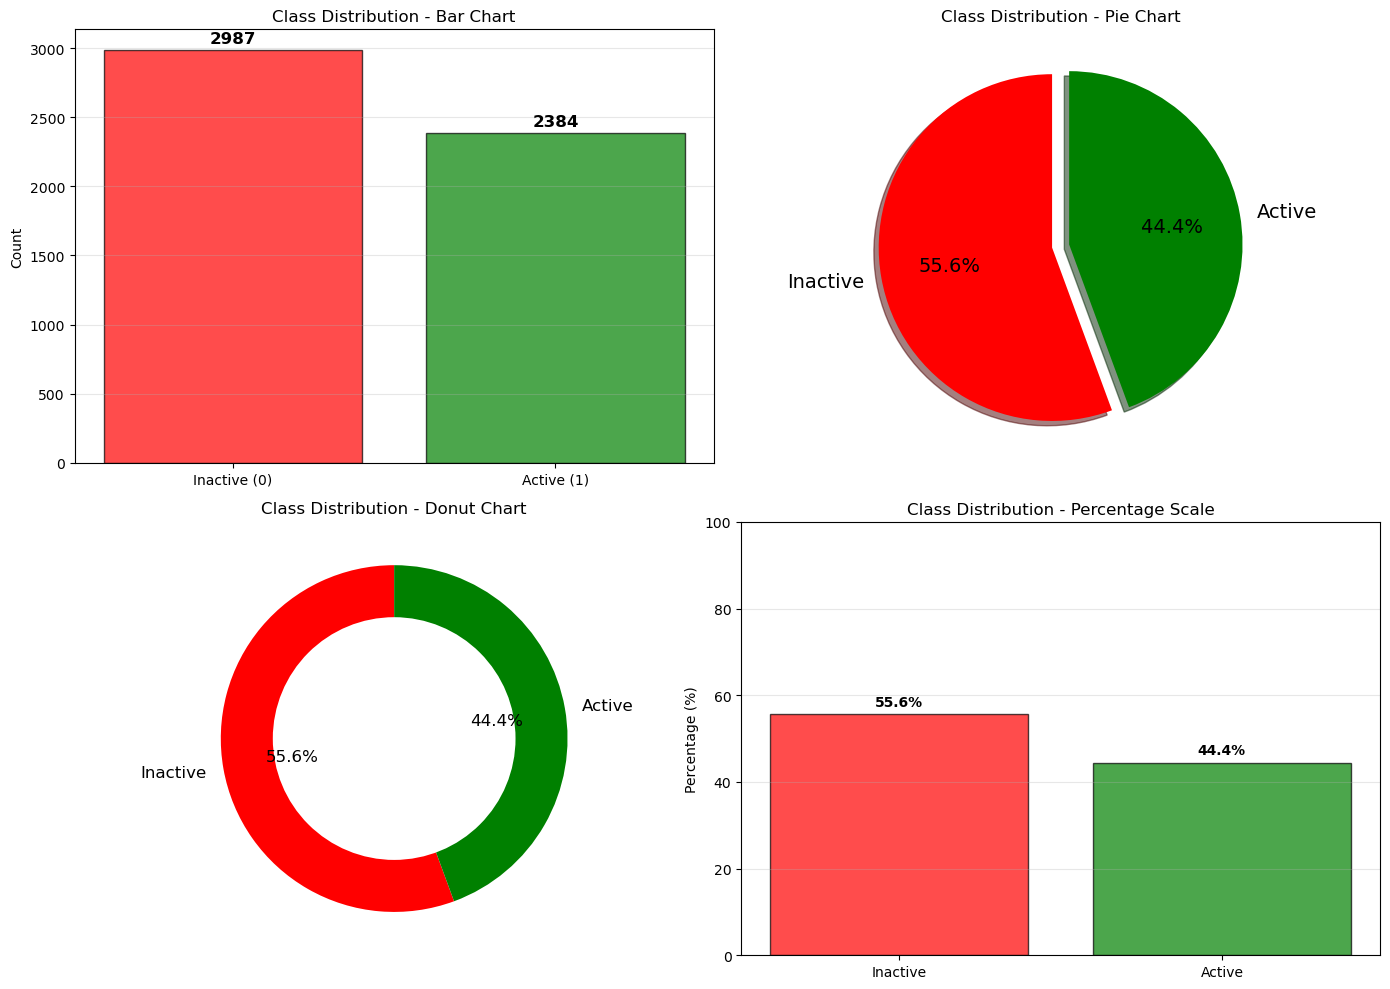


2. CLASS BALANCE METRICS
----------------------------------------
Imbalance ratio: 1.253 (1.0 = perfectly balanced)
Balance status: Well balanced

3. CLASS DISTRIBUTION ACROSS pIC50 RANGES
----------------------------------------


C:\Users\HP\AppData\Local\Temp\ipykernel_11384\3800084558.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby(['pic50_bin', 'active']).size().unstack(fill_value=0)


,Inactive,Active,Total,% Active
pic50_bin,,,,
"(0.639, 1.707]",6,0,6,0.0
"(1.707, 2.764]",25,0,25,0.0
"(2.764, 3.821]",144,0,144,0.0
"(3.821, 4.878]",1160,0,1160,0.0
"(4.878, 5.935]",1519,0,1519,0.0
"(5.935, 6.992]",133,1229,1362,90.2
"(6.992, 8.049]",0,922,922,100.0
"(8.049, 9.106]",0,211,211,100.0
"(9.106, 10.163]",0,18,18,100.0


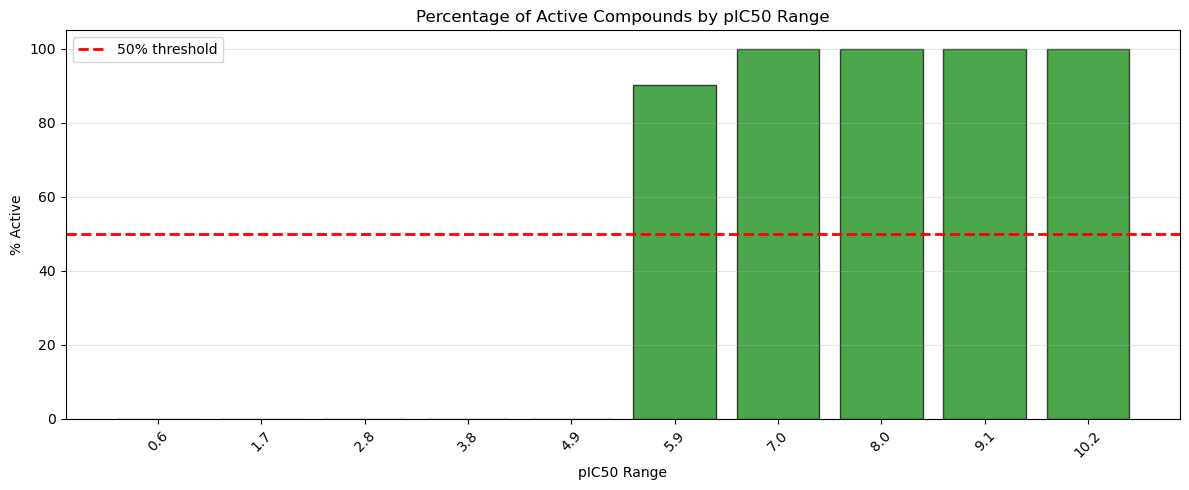


4. SUMMARY
----------------------------------------
Total molecules: 5371
Active: 2384 (44.4%)
Inactive: 2987 (55.6%)
Difference: 603 molecules

✓ Class balance analysis complete


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data
df = pd.read_csv('cox2_chembl_fingerprints.csv')
print("ACTIVE VS INACTIVE CLASS BALANCE ANALYSIS")
print("=" * 70)

# Count active and inactive
active_count = df['active'].sum()
inactive_count = len(df) - active_count
total = len(df)

print("\n1. CLASS COUNTS")
print("-" * 40)
count_df = pd.DataFrame({
    'Class': ['Active (1)', 'Inactive (0)', 'Total'],
    'Count': [active_count, inactive_count, total],
    'Percentage': [
        f"{active_count/total*100:.2f}%",
        f"{inactive_count/total*100:.2f}%",
        "100%"
    ]
})
display(count_df)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart
axes[0, 0].bar(['Inactive (0)', 'Active (1)'], [inactive_count, active_count], 
               color=['red', 'green'], edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution - Bar Chart')
for i, v in enumerate([inactive_count, active_count]):
    axes[0, 0].text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Pie chart
colors = ['red', 'green']
explode = (0.05, 0.05)
axes[0, 1].pie([inactive_count, active_count], 
               labels=['Inactive', 'Active'],
               colors=colors, explode=explode, autopct='%1.1f%%',
               startangle=90, shadow=True, textprops={'fontsize': 14})
axes[0, 1].set_title('Class Distribution - Pie Chart')

# 3. Donut chart
wedges, texts, autotexts = axes[1, 0].pie([inactive_count, active_count], 
                                          labels=['Inactive', 'Active'],
                                          colors=colors, autopct='%1.1f%%',
                                          startangle=90, textprops={'fontsize': 12})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1, 0].add_artist(centre_circle)
axes[1, 0].set_title('Class Distribution - Donut Chart')

# 4. Stacked bar chart (100% scale)
axes[1, 1].bar(['Inactive', 'Active'], [inactive_count/total*100, active_count/total*100], 
               color=['red', 'green'], edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Class Distribution - Percentage Scale')
axes[1, 1].set_ylim(0, 100)
for i, v in enumerate([inactive_count/total*100, active_count/total*100]):
    axes[1, 1].text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Class balance metrics
print("\n2. CLASS BALANCE METRICS")
print("-" * 40)
imbalance_ratio = max(active_count, inactive_count) / min(active_count, inactive_count)
print(f"Imbalance ratio: {imbalance_ratio:.3f} (1.0 = perfectly balanced)")

if imbalance_ratio < 1.5:
    balance_status = "Well balanced"
elif imbalance_ratio < 3:
    balance_status = "Moderately imbalanced"
else:
    balance_status = "Severely imbalanced"

print(f"Balance status: {balance_status}")

# Distribution across pIC50 ranges
print("\n3. CLASS DISTRIBUTION ACROSS pIC50 RANGES")
print("-" * 40)

# Create pIC50 bins
df['pic50_bin'] = pd.cut(df['pIC50'], bins=10)
bin_counts = df.groupby(['pic50_bin', 'active']).size().unstack(fill_value=0)
bin_counts.columns = ['Inactive', 'Active']
bin_counts['Total'] = bin_counts['Inactive'] + bin_counts['Active']
bin_counts['% Active'] = (bin_counts['Active'] / bin_counts['Total'] * 100).round(1)
display(bin_counts)

# Visualization of active percentage by pIC50 range
plt.figure(figsize=(12, 5))
bins = [f"{interval:.1f}" for interval in bin_counts.index.categories.left]
plt.bar(range(len(bins)), bin_counts['% Active'].values, color='green', alpha=0.7, edgecolor='black')
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='50% threshold')
plt.xlabel('pIC50 Range')
plt.ylabel('% Active')
plt.title('Percentage of Active Compounds by pIC50 Range')
plt.xticks(range(len(bins)), [f"{b:.1f}" for b in bin_counts.index.categories.left], rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
print("\n4. SUMMARY")
print("-" * 40)
print(f"Total molecules: {total}")
print(f"Active: {active_count} ({active_count/total*100:.1f}%)")
print(f"Inactive: {inactive_count} ({inactive_count/total*100:.1f}%)")
print(f"Difference: {abs(active_count - inactive_count)} molecules")
print(f"\n✓ Class balance analysis complete")

"The dataset is well-balanced with 44.4% active and 55.6% inactive compounds (imbalance ratio is fine). As expected, the percentage of active compounds increases with pIC50, crossing 50% around pIC50 6.0-6.5, which validates our threshold choice. This balanced distribution is ideal for classification without needing special techniques."